Running 15-Fold CV for Lasso...
Lasso Metrics -> ACC: 0.916±0.032 | AUC: 0.955±0.022 | F1: 0.824±0.070


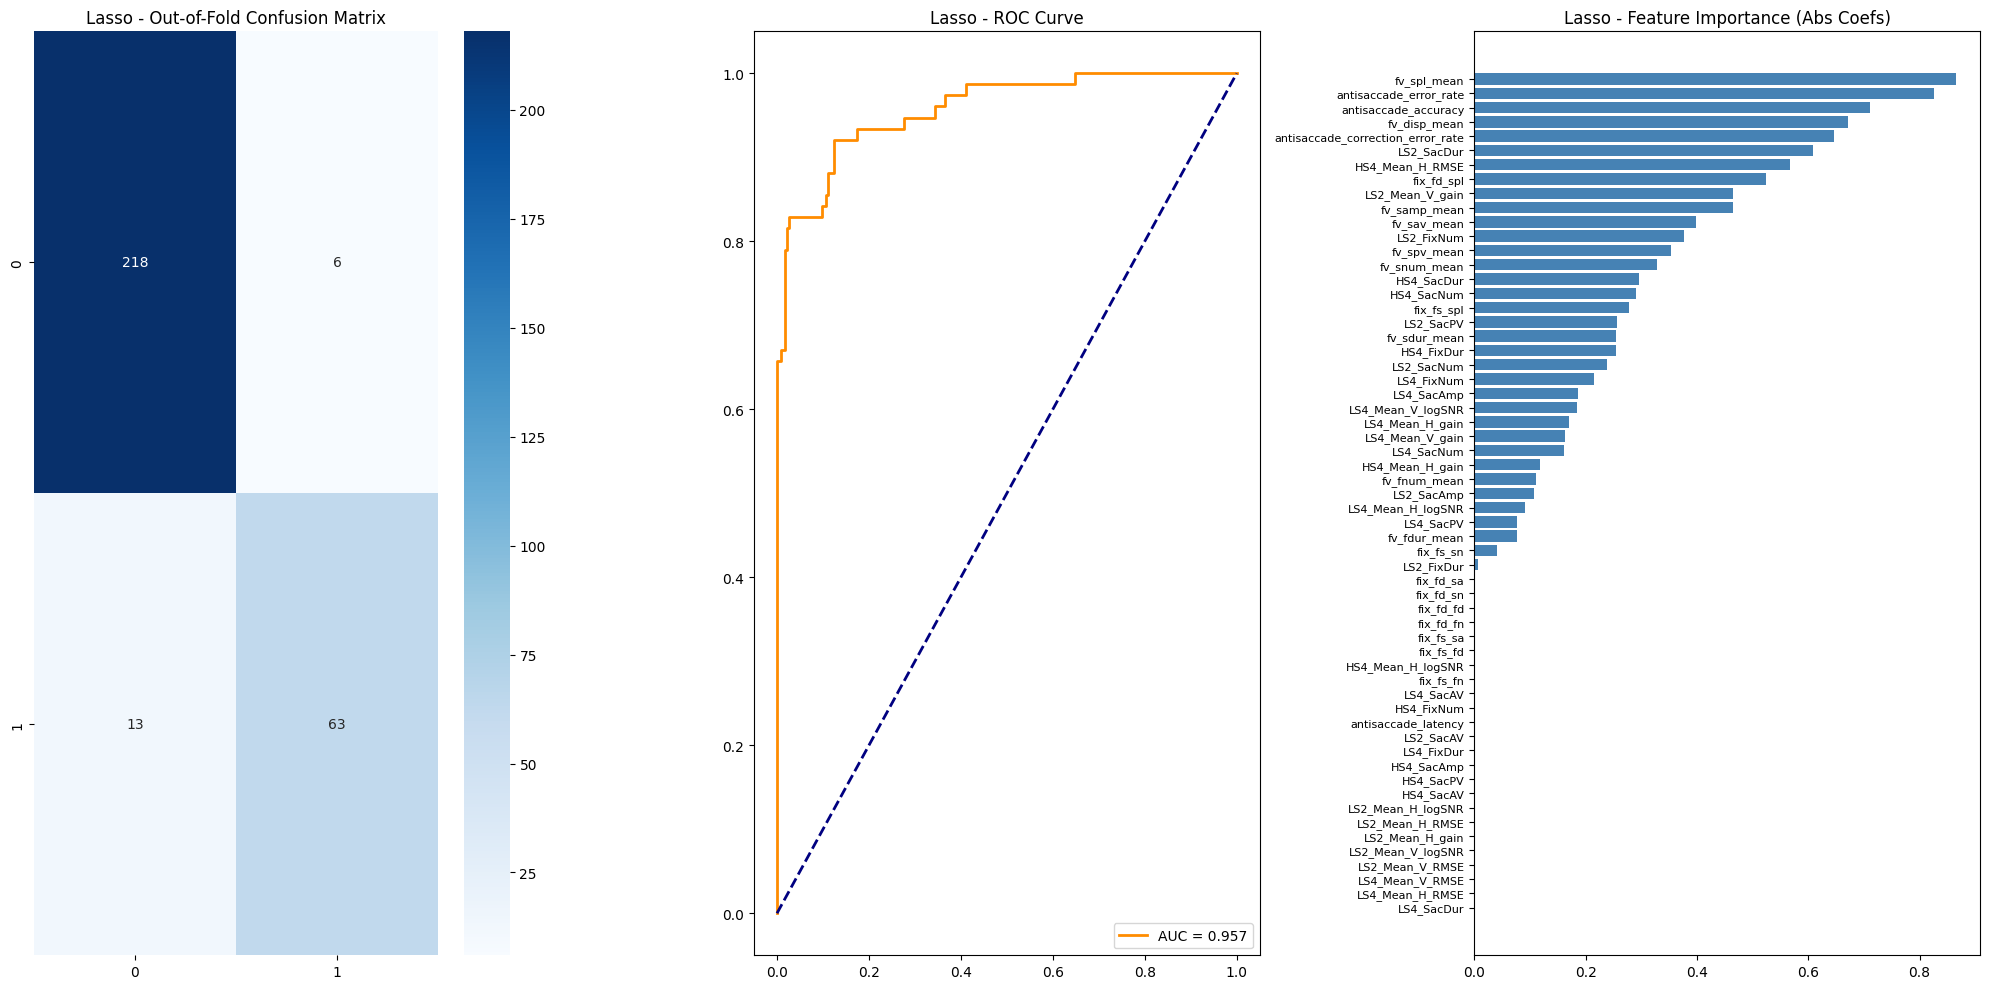

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression

# 1. Load Data
df = pd.read_csv('synthetic_eye_tracking_HC_SZ_300.csv')
X = df.drop(columns=['subject_id', 'label', 'calibration_error'])
y = LabelEncoder().fit_transform(df['label'])
feature_names = X.columns.tolist()

# 2. Repeated Stratified CV (For Paper Metrics)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)
accs, aucs, f1s = [], [], []

print("Running 15-Fold CV for Lasso...")
for train_idx, val_idx in rskf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    preds = model.predict(X_val_scaled)
    probs = model.predict_proba(X_val_scaled)[:, 1]
    
    accs.append(accuracy_score(y_val, preds))
    aucs.append(roc_auc_score(y_val, probs))
    f1s.append(f1_score(y_val, preds))

print(f"Lasso Metrics -> ACC: {np.mean(accs):.3f}±{np.std(accs):.3f} | AUC: {np.mean(aucs):.3f}±{np.std(aucs):.3f} | F1: {np.mean(f1s):.3f}±{np.std(f1s):.3f}")

# 3. Out-Of-Fold Predictions (For CSV, CM, ROC)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds, oof_probs = np.zeros(len(y)), np.zeros(len(y))

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    
    model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
    model.fit(X_train_scaled, y[train_idx])
    oof_preds[val_idx] = model.predict(X_val_scaled)
    oof_probs[val_idx] = model.predict_proba(X_val_scaled)[:, 1]

pd.DataFrame({
    'subject_id': df['subject_id'], 'actual_label': y,
    'predicted_label': oof_preds, 'predicted_prob': oof_probs, 'calibration_error': df['calibration_error']
}).to_csv('predictions_lasso.csv', index=False)

# 4. Final Model on FULL Data (For Save & Feature Importance)
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X)
final_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
final_model.fit(X_scaled, y)
joblib.dump(final_model, 'model_lasso.joblib')

# 5. Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
sns.heatmap(confusion_matrix(y, oof_preds), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Lasso - Out-of-Fold Confusion Matrix")

fpr, tpr, _ = roc_curve(y, oof_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y, oof_probs):.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title("Lasso - ROC Curve")
axes[1].legend(loc="lower right")

importances = np.abs(final_model.coef_[0])
indices = np.argsort(importances)
axes[2].barh(range(len(indices)), importances[indices], color='steelblue')
axes[2].set_yticks(range(len(indices)))
axes[2].set_yticklabels([feature_names[i] for i in indices], fontsize=8)
axes[2].set_title("Lasso - Feature Importance (Abs Coefs)")
plt.tight_layout()
plt.show()